In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data, add_high_cost_flags
from data.model_features import (
    get_grouped_model_feature_columns,
    split_feature_types
)
from export.report_exports import (
    create_report_output_dirs,
    export_report_table,
    save_report_figure,
    set_report_plot_style,
)

NOTEBOOK_NAME = "02_model_choice_diagnostics"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

CATEGORICAL_TABLE_DIR = TABLE_DIR / "Categorical_Summaries"
BINNED_TABLE_DIR = TABLE_DIR / "Binned_Summaries"

CATEGORICAL_TABLE_DIR.mkdir(parents=True, exist_ok=True)
BINNED_TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
set_report_plot_style()

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = "log1p_annual_medical_cost"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

print("Shape:", df.shape)
display(df.head())

data_summary_table = data_summary(df)
display(data_summary_table)

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_data_summary.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_data_summary.csv')

In [3]:
diagnostic_features = get_grouped_model_feature_columns(
    df,
    target_col=target
)

numeric_features, categorical_features = split_feature_types(
    df,
    diagnostic_features
)
print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical features:
['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier', 'hospitalizations_grouped', 'chronic_count_grouped', 'days_hospitalized_grouped']


In [4]:
corr_rows = []

for col in numeric_features:
    corr_rows.append({
        "feature": col,
        "spearman_with_cost": df[[col, target]].corr(method="spearman").iloc[0, 1],
        "spearman_with_log_cost": df[[col, log_target]].corr(method="spearman").iloc[0, 1]
    })

corr_table = (
    pd.DataFrame(corr_rows)
    .sort_values("spearman_with_log_cost", ascending=False)
    .round(4)
)

display(corr_table)

export_report_table(
    table=corr_table,
    table_dir=TABLE_DIR,
    file_stem="tab_02_numeric_spearman_correlations",
    caption="Spearman correlations between numeric predictors and annual medical cost.",
    label="tab:02-numeric-spearman-correlations",
    index=False,
    float_format="%.4f",
)

,feature,spearman_with_cost,spearman_with_log_cost
16,risk_score,0.3628,0.3628
32,is_high_risk,0.2981,0.2981
5,visits_last_year,0.2056,0.2056
17,hypertension,0.1791,0.1791
7,systolic_bp,0.1701,0.1701
0,age,0.1648,0.1648
33,had_major_procedure,0.1499,0.1499
26,mental_health,0.1424,0.1424
8,diastolic_bp,0.1384,0.1384
25,arthritis,0.1336,0.1336


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_numeric_spearman_correlations.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_numeric_spearman_correlations.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_numeric_spearman_correlations.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_numeric_spearman_correlations.tex')}

In [5]:
def binned_target_summary(
        data: pd.DataFrame,
        feature_col: str,
        target_col: str,
        bins: int = 10
) -> pd.DataFrame:
    temp = data[[feature_col, target_col]].dropna().copy()

    bin_col = f"{feature_col}_bin"

    temp[bin_col] = pd.qcut(
        temp[feature_col],
        q=bins,
        duplicates="drop"
    )

    binned_summary = (
        temp.groupby(bin_col, observed=True)
        .agg(
            n=(target_col, "size"),
            mean=(target_col, "mean"),
            median=(target_col, "median"),
            p90=(target_col, lambda x: x.quantile(0.90)),
            p95=(target_col, lambda x: x.quantile(0.95))
        )
        .reset_index()
    )

    binned_summary["bin_midpoint"] = binned_summary[bin_col].map(
        lambda interval: interval.mid
    ).astype(float)

    return binned_summary

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_age.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_age.png


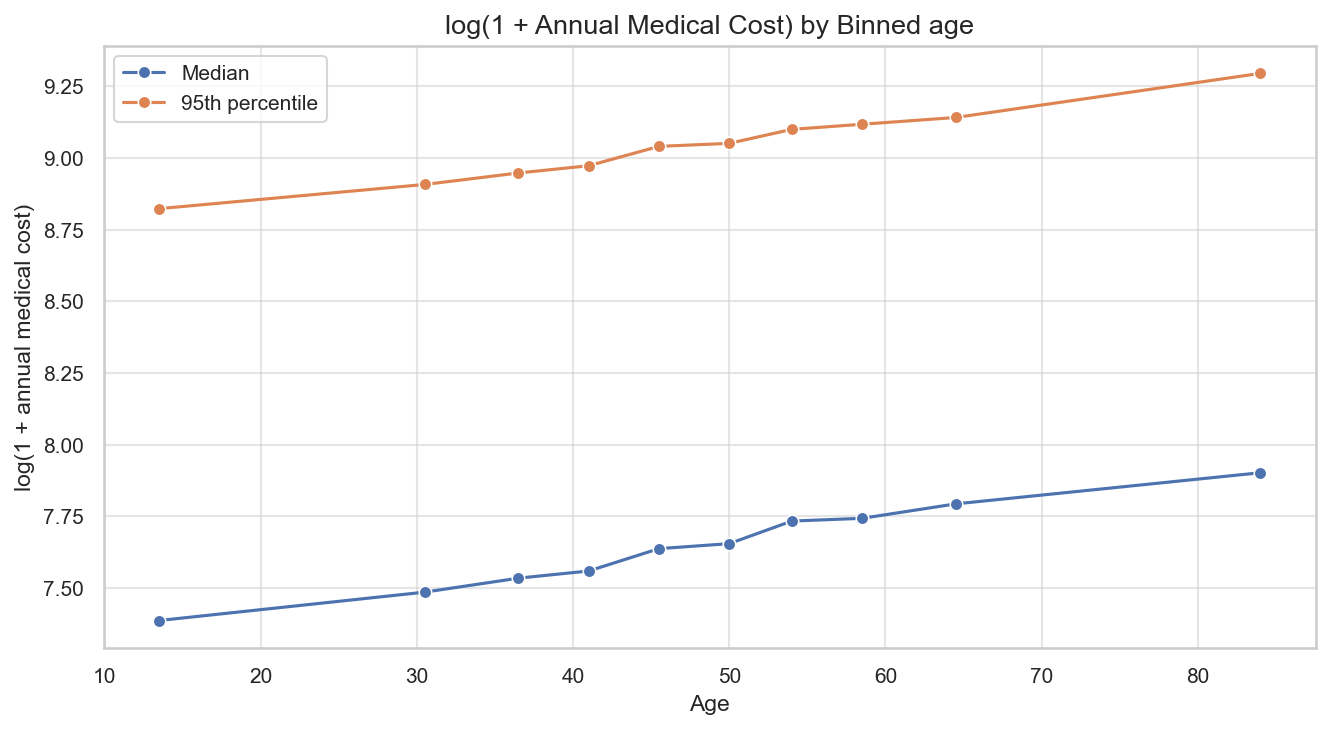

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_bmi.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_bmi.png


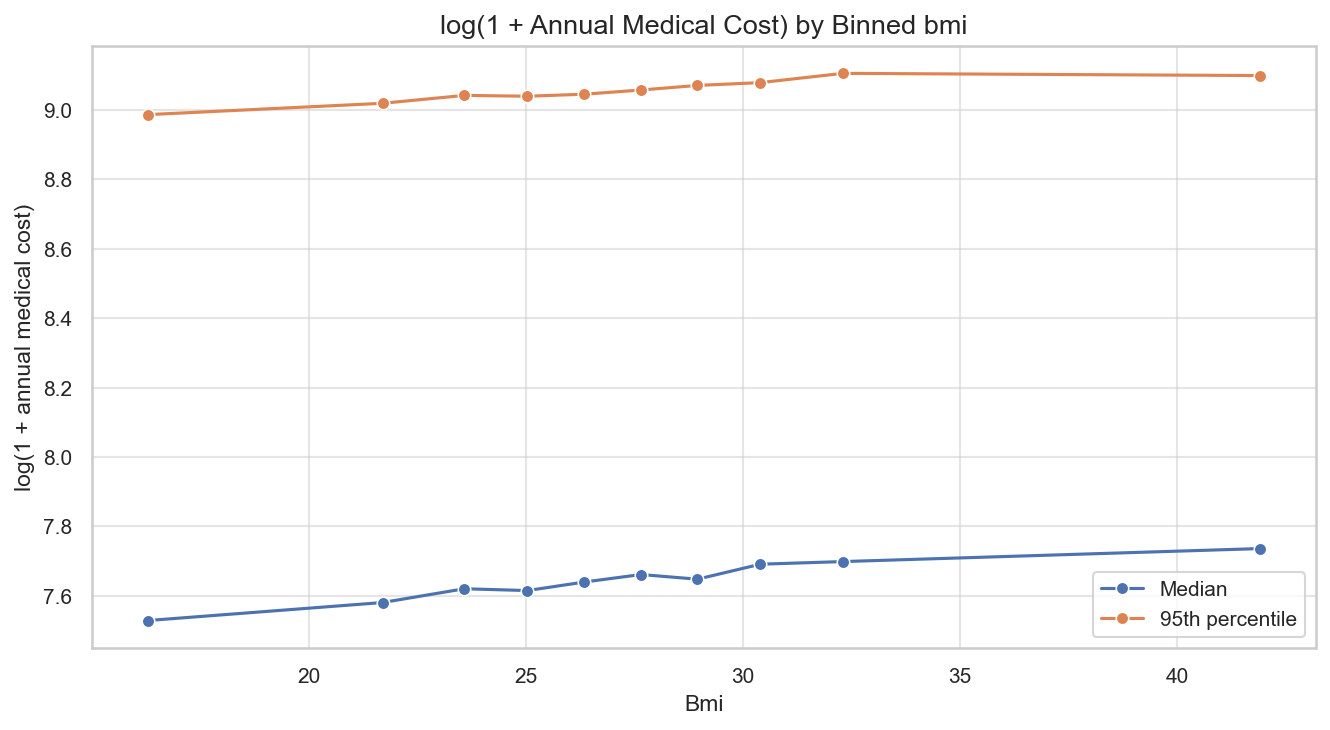

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_income.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_income.png


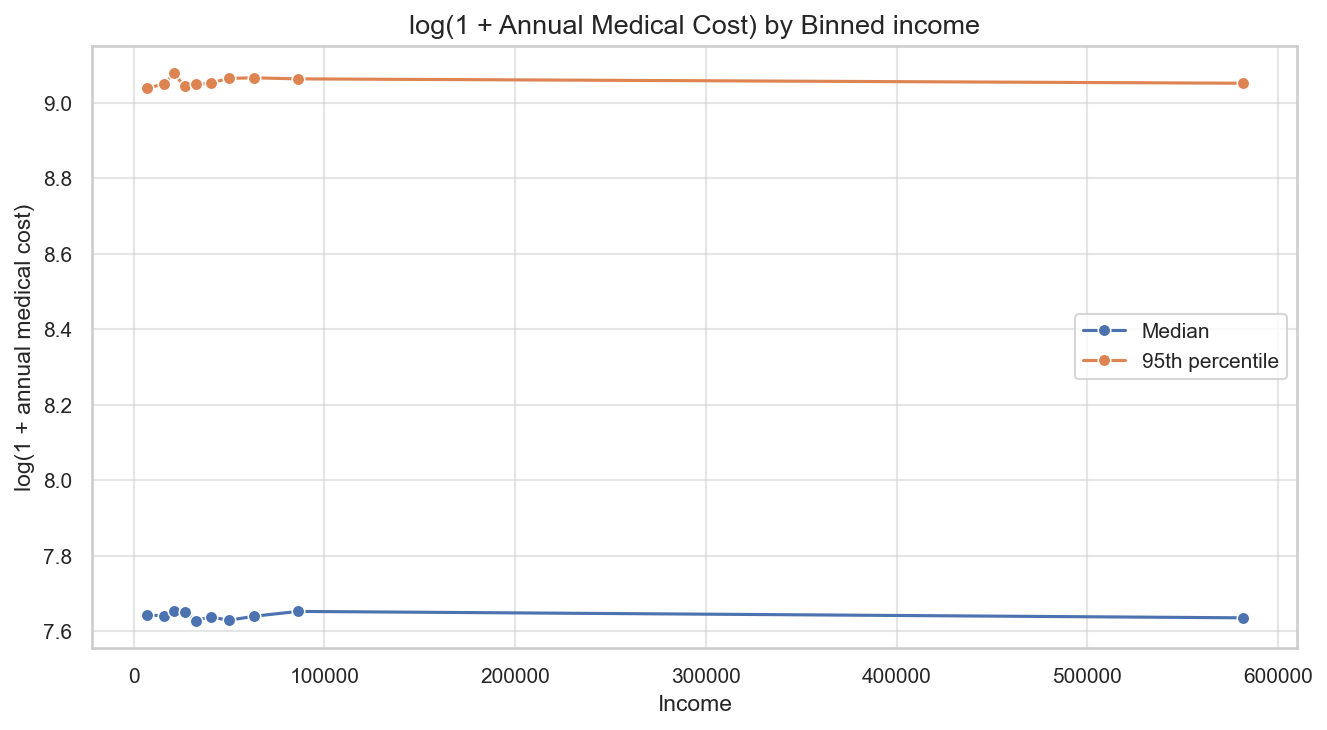

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_risk_score.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_risk_score.png


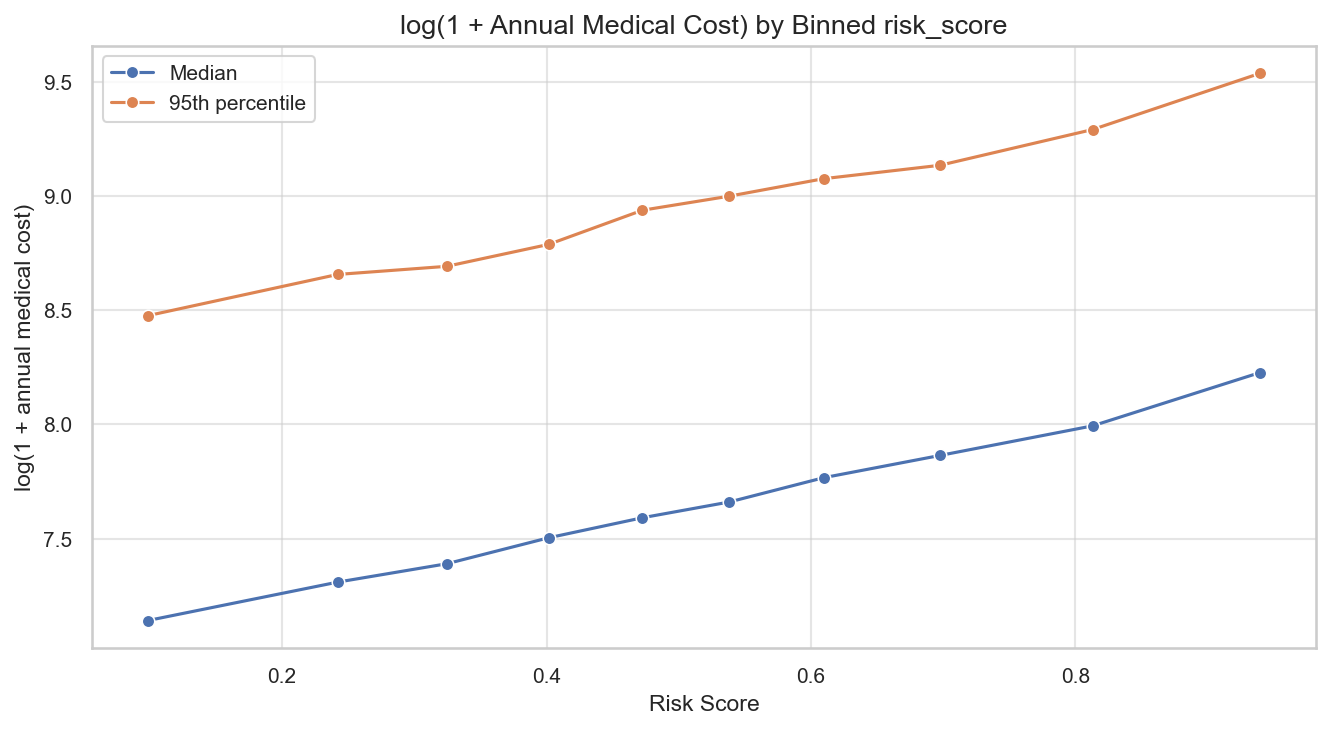

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_visits_last_year.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_visits_last_year.png


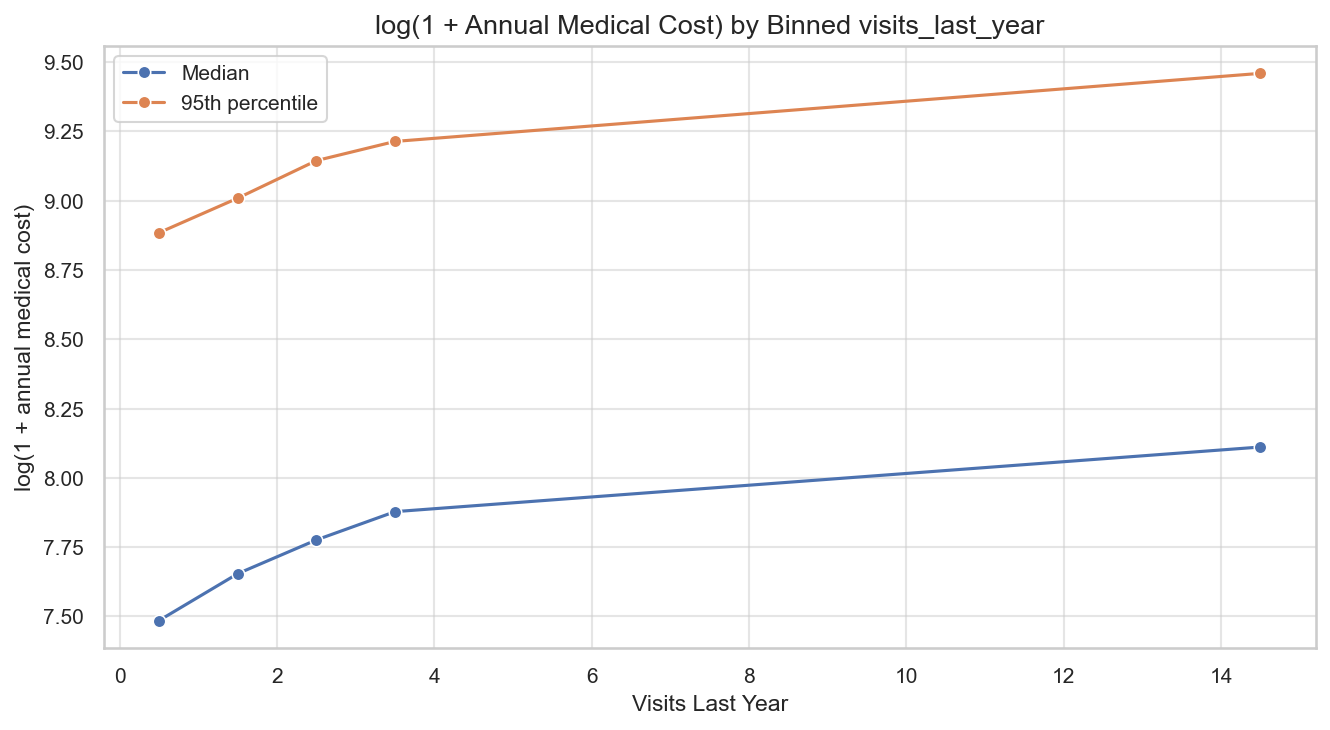

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_medication_count.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_medication_count.png


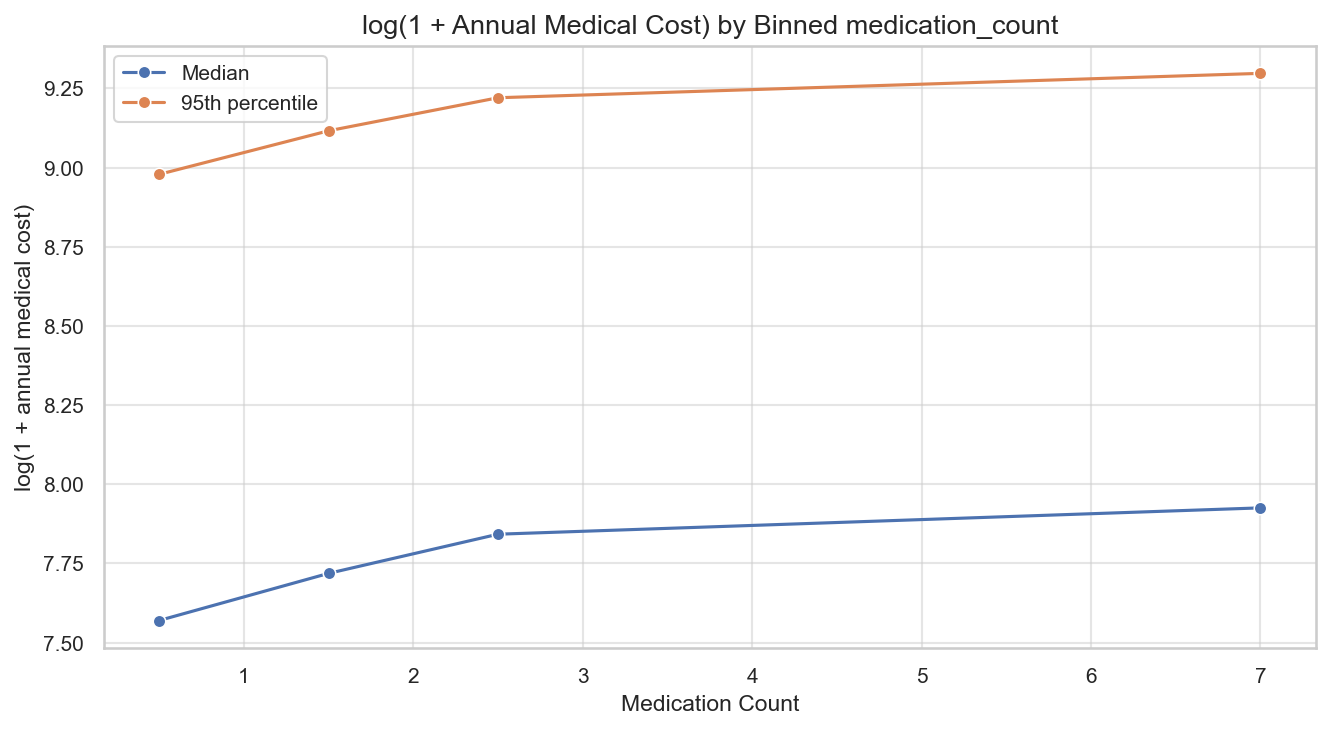

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Binned_Summaries\tab_02_binned_log_cost_by_provider_quality.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_binned_log_cost_by_provider_quality.png


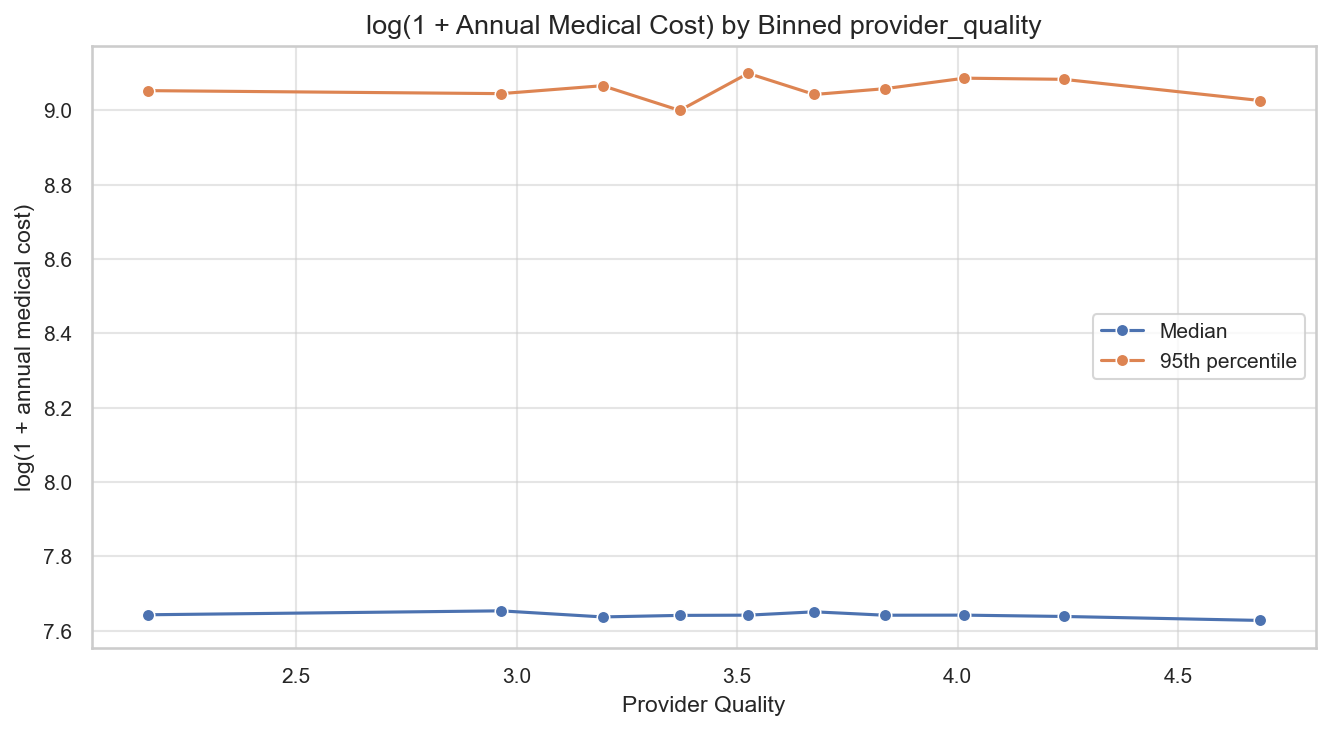

In [6]:
key_numeric_features = [
    "age",
    "bmi",
    "income",
    "risk_score",
    "visits_last_year",
    "medication_count",
    "provider_quality",
]

binned_summary_tables = {}

for feature in key_numeric_features:
    summary = binned_target_summary(df, feature, log_target)
    binned_summary_tables[feature] = summary

    fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

    sns.lineplot(
        data=summary,
        x="bin_midpoint",
        y="median",
        marker="o",
        label="Median",
        ax=ax,
    )

    sns.lineplot(
        data=summary,
        x="bin_midpoint",
        y="p95",
        marker="o",
        label="95th percentile",
        ax=ax,
    )

    ax.set_title(f"log(1 + Annual Medical Cost) by Binned {feature}")
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel("log(1 + annual medical cost)")
    ax.legend()

    fig.tight_layout()

    save_report_figure(
        fig=fig,
        figure_dir=FIGURE_DIR,
        file_stem=f"fig_02_binned_log_cost_by_{feature}",
    )

    plt.show()

In [7]:
days_hospitalized_summary = (
    df.groupby("days_hospitalized_grouped", observed=True)
    .agg(
        n=(target, "size"),
        mean_cost=(target, "mean"),
        median_cost=(target, "median"),
        p90_cost=(target, lambda x: x.quantile(0.90)),
        p95_cost=(target, lambda x: x.quantile(0.95)),
        p99_cost=(target, lambda x: x.quantile(0.99))
    )
    .round(2)
)

display(days_hospitalized_summary)

,n,mean_cost,median_cost,p90_cost,p95_cost,p99_cost
days_hospitalized_grouped,,,,,,
0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1-3,3778,3948.33,2783.03,8104.42,10938.19,19498.08
4+,5191,5816.02,4274.31,11443.71,15598.54,26651.07


In [8]:
days_hospitalized_summary_export = (
    days_hospitalized_summary
    .reset_index()
    .rename(columns={
        "days_hospitalized_grouped": "Days hospitalised in last 3 years",
        "n": "n",
        "mean_cost": "Mean cost (USD)",
        "median_cost": "Median cost (USD)",
        "p90_cost": "p90 cost (USD)",
        "p95_cost": "p95 cost (USD)",
        "p99_cost": "p99 cost (USD)",
    })
)

display(days_hospitalized_summary_export)

export_report_table(
    table=days_hospitalized_summary_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_days_hospitalised_grouped_summary",
    caption="Annual medical cost by grouped days hospitalised.",
    label="tab:02-days-hospitalised-grouped-summary",
    index=False,
)

,Days hospitalised in last 3 years,n,Mean cost (USD),Median cost (USD),p90 cost (USD),p95 cost (USD),p99 cost (USD)
0,0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1,1-3,3778,3948.33,2783.03,8104.42,10938.19,19498.08
2,4+,5191,5816.02,4274.31,11443.71,15598.54,26651.07


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_days_hospitalised_grouped_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_days_hospitalised_grouped_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_days_hospitalised_grouped_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_days_hospitalised_grouped_summary.tex')}

In [9]:
def categorical_target_summary(
        data: pd.DataFrame,
        feature_col: str,
        target_col: str
) -> pd.DataFrame:
    result = (
        data.groupby(feature_col, dropna=False)
        .agg(
            n=(target_col, "size"),
            mean=(target_col, "mean"),
            median=(target_col, "median"),
            p90=(target_col, lambda x: x.quantile(0.90)),
            p95=(target_col, lambda x: x.quantile(0.95)),
            p99=(target_col, lambda x: x.quantile(0.99))
        )
        .sort_values("median", ascending=False)
        .round(2)
    )

    return result

In [10]:
categorical_summary_tables = {}

for categorical_col in categorical_features:
    print(f"\n{categorical_col}")

    summary = categorical_target_summary(
        df,
        categorical_col,
        target,
    )

    categorical_summary_tables[categorical_col] = summary

    display(summary)


sex


,n,mean,median,p90,p95,p99
sex,,,,,,
Male,48794,3019.94,2094.80,6244.90,8590.27,15348.25
Other,2013,2985.34,2080.72,6196.64,8720.83,15226.26
Female,49193,3000.03,2070.83,6206.97,8543.56,15274.05


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Categorical_Summaries\tab_02_categorical_summary_sex.csv

region


,n,mean,median,p90,p95,p99
region,,,,,,
South,28029,3044.08,2100.56,6301.56,8860.03,15746.30
West,17879,3022.91,2095.87,6206.18,8660.49,15405.05
Central,12081,2968.24,2077.61,6105.76,8367.75,14485.47
North,22027,3002.01,2069.00,6210.24,8465.47,15349.85
East,19984,2981.96,2062.03,6239.30,8361.75,14718.04


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Categorical_Summaries\tab_02_categorical_summary_region.csv

urban_rural


...

Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Categorical_Summaries\tab_02_categorical_summary_hospitalizations_grouped.csv

chronic_count_grouped


,n,mean,median,p90,p95,p99
chronic_count_grouped,,,,,,
4+,326,7260.65,5260.05,15120.21,19244.68,30407.02
3,2452,5671.43,4137.85,11207.64,15269.95,26076.46
2,13111,4438.19,3249.83,8993.14,12001.39,20854.28
1,37579,3332.01,2415.40,6711.20,9023.71,15586.62
0,46532,2176.33,1558.97,4396.05,5949.58,10487.04


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Categorical_Summaries\tab_02_categorical_summary_chronic_count_grouped.csv

days_hospitalized_grouped


,n,mean,median,p90,p95,p99
days_hospitalized_grouped,,,,,,
4+,5191,5816.02,4274.31,11443.71,15598.54,26651.07
1-3,3778,3948.33,2783.03,8104.42,10938.19,19498.08
0,91031,2810.44,1977.55,5794.89,7889.32,13910.33


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\Categorical_Summaries\tab_02_categorical_summary_days_hospitalized_grouped.csv


In [11]:
p90 = df[target].quantile(0.90)
p95 = df[target].quantile(0.95)
p99 = df[target].quantile(0.99)

df = add_high_cost_flags(
    df,
    target_col=target,
    quantiles=(0.90, 0.95, 0.99)
)

print("90th percentile:", round(p90, 2))
print("95th percentile:", round(p95, 2))
print("99th percentile:", round(p99, 2))

high_cost_threshold_table = pd.DataFrame({
    "Quantile": [
        "90th percentile",
        "95th percentile",
        "99th percentile",
    ],
    "Threshold (USD)": [
        p90,
        p95,
        p99,
    ],
    "High-cost flag": [
        "high_cost_90",
        "high_cost_95",
        "high_cost_99",
    ],
})

display(high_cost_threshold_table)

export_report_table(
    table=high_cost_threshold_table,
    table_dir=TABLE_DIR,
    file_stem="tab_02_high_cost_thresholds",
    caption="Empirical high-cost thresholds used for tail-risk diagnostics.",
    label="tab:02-high-cost-thresholds",
    index=False,
)

90th percentile: 6227.09
95th percentile: 8570.35
99th percentile: 15293.68


,Quantile,Threshold (USD),High-cost flag
0,90th percentile,6227.0920,high_cost_90
1,95th percentile,8570.3505,high_cost_95
2,99th percentile,15293.6822,high_cost_99


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_high_cost_thresholds.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_high_cost_thresholds.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_high_cost_thresholds.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_high_cost_thresholds.tex')}

In [12]:
tail_by_hospital = (
    df.groupby("hospitalizations_grouped", observed=True)
    .agg(
        n=("annual_medical_cost", "size"),
        mean_cost=("annual_medical_cost", "mean"),
        p95_cost=("annual_medical_cost", lambda x: x.quantile(0.95)),
        p99_cost=("annual_medical_cost", lambda x: x.quantile(0.99)),
        high_cost_95_rate=("high_cost_95", "mean"),
        high_cost_99_rate=("high_cost_99", "mean")
    )
    .round(4)
)

tail_by_hospital

,n,mean_cost,p95_cost,p99_cost,high_cost_95_rate,high_cost_99_rate
hospitalizations_grouped,,,,,,
0,91031,2810.4431,7889.320,13910.3260,0.0405,0.0072
1,8582,4919.6337,13216.472,23232.6995,0.1398,0.0351
2+,387,7461.1096,20864.746,30406.7422,0.2894,0.1163


In [13]:
tail_by_hospital_export = (
    tail_by_hospital
    .reset_index()
    .rename(columns={
        "hospitalizations_grouped": "Hospitalisations in last 3 years",
        "n": "n",
        "mean_cost": "Mean cost (USD)",
        "p95_cost": "p95 cost (USD)",
        "p99_cost": "p99 cost (USD)",
        "high_cost_95_rate": "High-cost 95 rate",
        "high_cost_99_rate": "High-cost 99 rate",
    })
)

display(tail_by_hospital_export)

export_report_table(
    table=tail_by_hospital_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_tail_by_hospitalisation",
    caption="Upper-tail cost diagnostics by grouped hospitalisation history.",
    label="tab:02-tail-by-hospitalisation",
    index=False,
    float_format="%.4f",
)

,Hospitalisations in last 3 years,n,Mean cost (USD),p95 cost (USD),p99 cost (USD),High-cost 95 rate,High-cost 99 rate
0,0,91031,2810.4431,7889.320,13910.3260,0.0405,0.0072
1,1,8582,4919.6337,13216.472,23232.6995,0.1398,0.0351
2,2+,387,7461.1096,20864.746,30406.7422,0.2894,0.1163


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_by_hospitalisation.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_by_hospitalisation.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_tail_by_hospitalisation.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_tail_by_hospitalisation.tex')}

In [14]:
tail_by_chronic = (
    df.groupby("chronic_count_grouped", observed=True)
    .agg(
        n=("annual_medical_cost", "size"),
        mean_cost=("annual_medical_cost", "mean"),
        p95_cost=("annual_medical_cost", lambda x: x.quantile(0.95)),
        p99_cost=("annual_medical_cost", lambda x: x.quantile(0.99)),
        high_cost_95_rate=("high_cost_95", "mean"),
        high_cost_99_rate=("high_cost_99", "mean")
    )
    .round(4)
)

tail_by_chronic

,n,mean_cost,p95_cost,p99_cost,high_cost_95_rate,high_cost_99_rate
chronic_count_grouped,,,,,,
0,46532,2176.3317,5949.5805,10487.0442,0.0187,0.0026
1,37579,3332.0129,9023.7080,15586.6164,0.0574,0.0106
2,13111,4438.1893,12001.3900,20854.2780,0.1106,0.0248
3,2452,5671.4266,15269.9545,26076.4563,0.1778,0.0498
4+,326,7260.6473,19244.6775,30407.0175,0.2761,0.0982


In [15]:
tail_by_chronic_export = (
    tail_by_chronic
    .reset_index()
    .rename(columns={
        "chronic_count_grouped": "Chronic disease count group",
        "n": "n",
        "mean_cost": "Mean cost (USD)",
        "p95_cost": "p95 cost (USD)",
        "p99_cost": "p99 cost (USD)",
        "high_cost_95_rate": "High-cost 95 rate",
        "high_cost_99_rate": "High-cost 99 rate",
    })
)

display(tail_by_chronic_export)

export_report_table(
    table=tail_by_chronic_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_tail_by_chronic_count",
    caption="Upper-tail cost diagnostics by grouped chronic disease count.",
    label="tab:02-tail-by-chronic-count",
    index=False,
    float_format="%.4f",
)

,Chronic disease count group,n,Mean cost (USD),p95 cost (USD),p99 cost (USD),High-cost 95 rate,High-cost 99 rate
0,0,46532,2176.3317,5949.5805,10487.0442,0.0187,0.0026
1,1,37579,3332.0129,9023.7080,15586.6164,0.0574,0.0106
2,2,13111,4438.1893,12001.3900,20854.2780,0.1106,0.0248
3,3,2452,5671.4266,15269.9545,26076.4563,0.1778,0.0498
4,4+,326,7260.6473,19244.6775,30407.0175,0.2761,0.0982


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_by_chronic_count.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_by_chronic_count.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_tail_by_chronic_count.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_tail_by_chronic_count.tex')}

In [16]:
interaction_median = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc="median",
    observed=True
).round(2)

interaction_p95 = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc=lambda x: x.quantile(0.95),
    observed=True
).round(2)

interaction_p99 = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc=lambda x: x.quantile(0.99),
    observed=True
).round(2)

interaction_counts = df.pivot_table(
    values=target,
    index="chronic_count_grouped",
    columns="hospitalizations_grouped",
    aggfunc="size",
    observed=True
)

display(interaction_median)
display(interaction_p95)
display(interaction_p99)
display(interaction_counts)

interaction_tables = {
    "interaction_counts": interaction_counts,
    "interaction_median_cost": interaction_median,
    "interaction_p95_cost": interaction_p95,
    "interaction_p99_cost": interaction_p99,
}

for table_name, table in interaction_tables.items():
    export_report_table(
        table=table,
        table_dir=TABLE_DIR,
        file_stem=f"tab_02_{table_name}",
        caption=f"Chronic disease and hospitalisation interaction table: {table_name.replace('_', ' ')}.",
        label=f"tab:02-{table_name.replace('_', '-')}",
        index=True,
        float_format="%.2f",
    )

hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,1492.50,2893.87,4269.22
1,2307.82,3740.04,5249.40
2,3118.88,4532.38,6037.24
3,3926.81,5201.54,6995.92
4+,4681.58,6367.56,17772.25


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,5439.79,10564.52,13609.73
1,8368.63,13528.17,22285.71
2,11258.44,15829.44,23355.06
3,14769.86,19509.05,24076.70
4+,18730.82,16942.82,20471.11


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,9245.16,18793.92,19753.40
1,14058.35,22983.96,29767.32
2,19037.18,29144.84,36586.30
3,24852.89,26376.26,28668.77
4+,34556.66,26119.39,20837.82


hospitalizations_grouped,0,1,2+
chronic_count_grouped,,,
0,43031,3375,126
1,33987,3441,151
2,11639,1392,80
3,2092,334,26
4+,282,40,4


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_interaction_counts.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_interaction_counts.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_interaction_median_cost.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_interaction_median_cost.tex
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_interaction_p95_cost.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_interaction_counts_heatmap.png


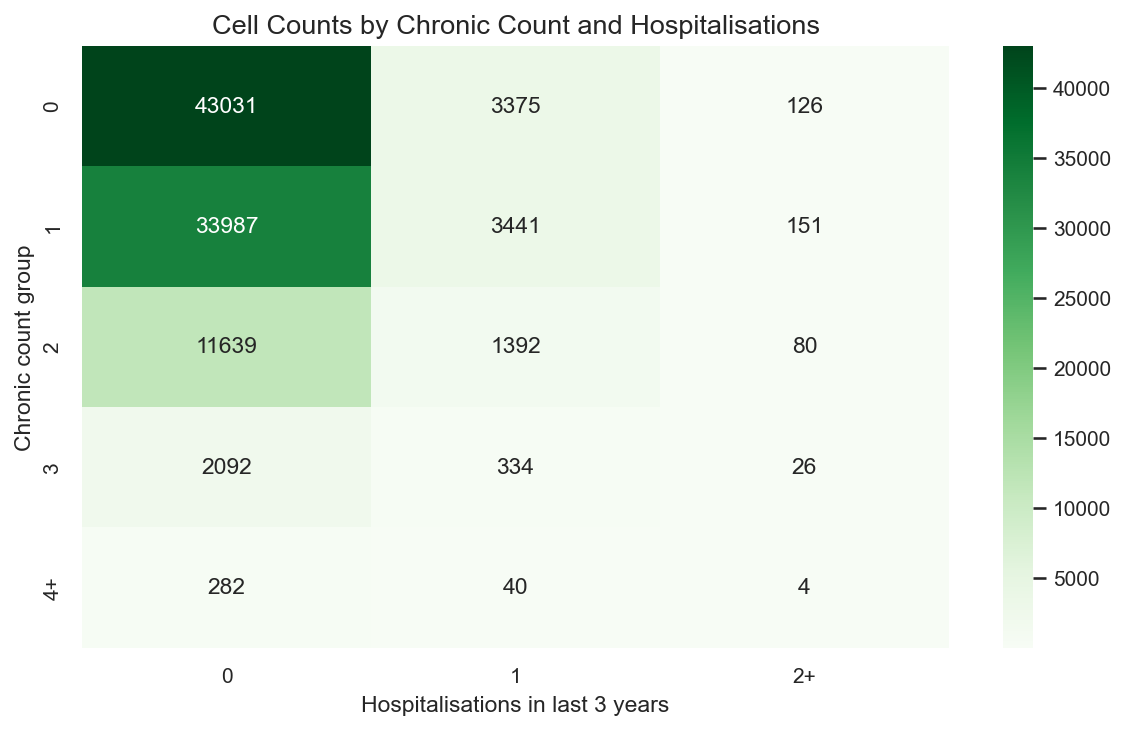

In [17]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_counts,
    annot=True,
    fmt=".0f",
    cmap="Greens",
    ax=ax,
)

ax.set_title("Cell Counts by Chronic Count and Hospitalisations")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("Chronic count group")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_interaction_counts_heatmap",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_interaction_median_cost_heatmap.png


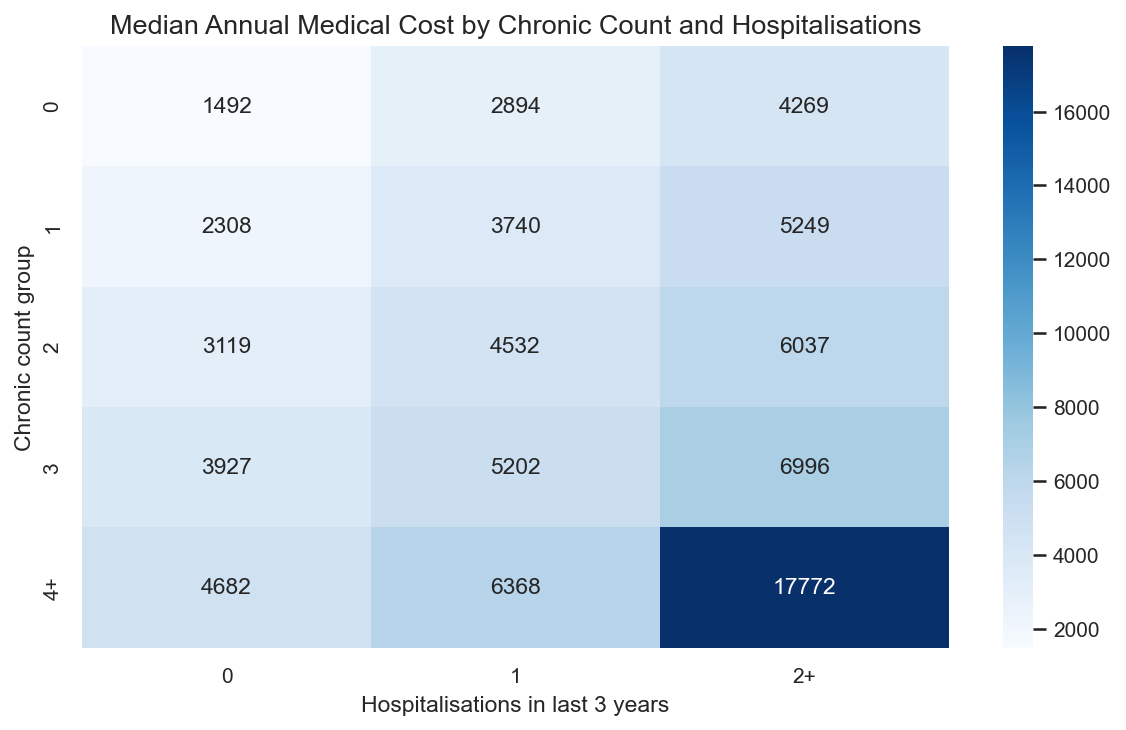

In [18]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_median,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    ax=ax,
)

ax.set_title("Median Annual Medical Cost by Chronic Count and Hospitalisations")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("Chronic count group")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_interaction_median_cost_heatmap",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_interaction_p95_cost_heatmap.png


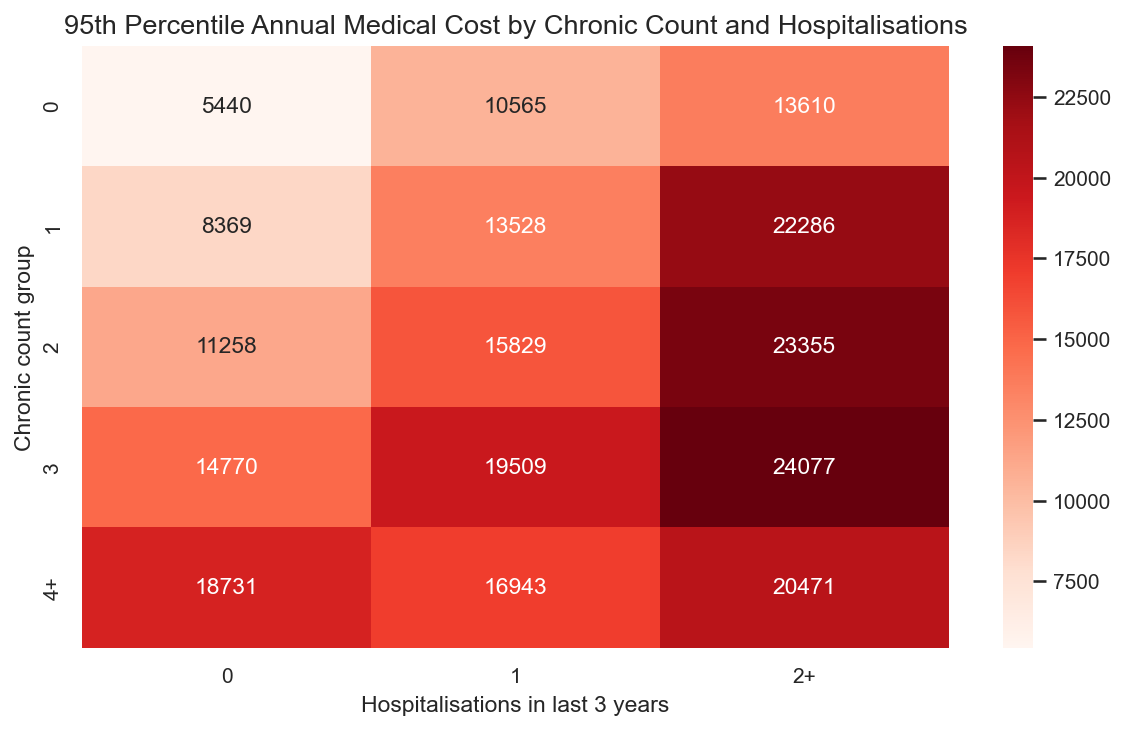

In [19]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_p95,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    ax=ax,
)

ax.set_title("95th Percentile Annual Medical Cost by Chronic Count and Hospitalisations")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("Chronic count group")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_interaction_p95_cost_heatmap",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_interaction_p99_cost_heatmap.png


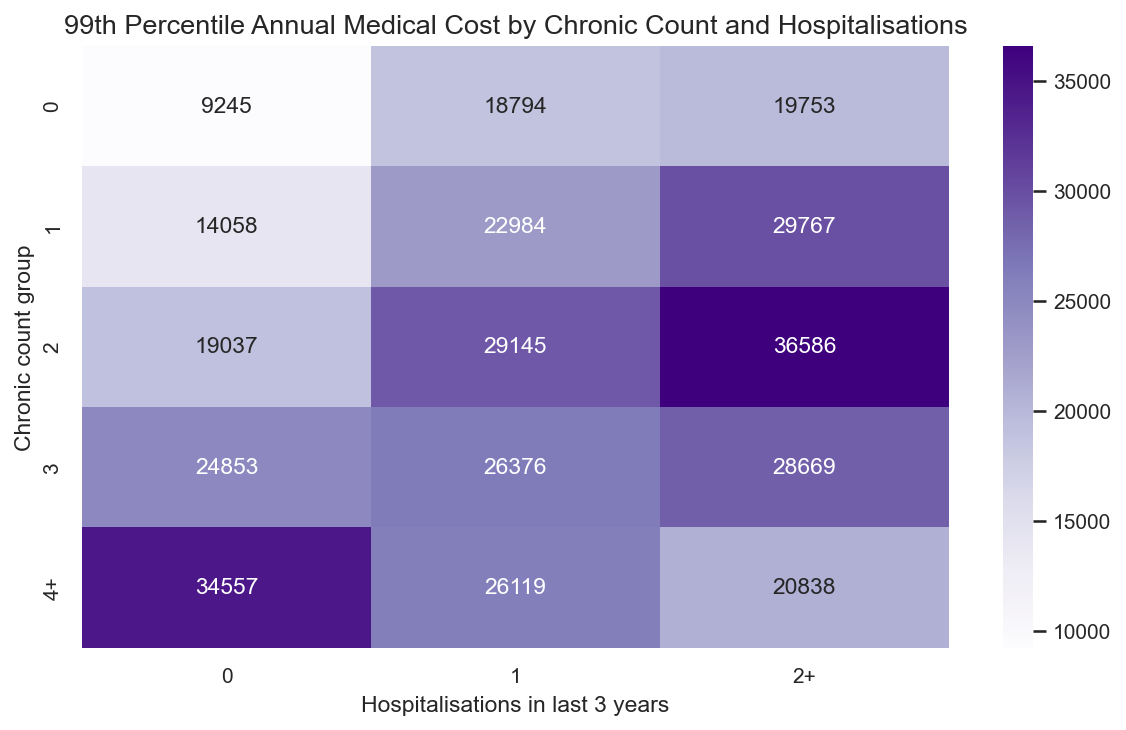

In [20]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.heatmap(
    interaction_p99,
    annot=True,
    fmt=".0f",
    cmap="Purples",
    ax=ax,
)

ax.set_title("99th Percentile Annual Medical Cost by Chronic Count and Hospitalisations")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("Chronic count group")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_interaction_p99_cost_heatmap",
)

plt.show()

In [21]:
df_sorted = df.sort_values(target, ascending=False).copy()

total_cost = df_sorted[target].sum()

tail_concentration = pd.DataFrame({
    "top_percent": [1, 2.5, 5, 10, 20],
    "n_policyholders": [
        int(len(df_sorted) * p / 100)
        for p in [1, 2.5, 5, 10, 20]
    ]
})

tail_concentration["cost_share"] = tail_concentration["n_policyholders"].apply(
    lambda n: df_sorted.head(n)[target].sum() / total_cost
)

tail_concentration["cost_share"] = tail_concentration["cost_share"].round(4)

tail_concentration

,top_percent,n_policyholders,cost_share
0,1.0,1000,0.0709
1,2.5,2500,0.1351
2,5.0,5000,0.2158
3,10.0,10000,0.3360
4,20.0,20000,0.5061


,Top policyholders (%),n policyholders,Cost share
0,1.0,1000,0.0709
1,2.5,2500,0.1351
2,5.0,5000,0.2158
3,10.0,10000,0.3360
4,20.0,20000,0.5061


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_concentration.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_tail_concentration.tex
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_tail_concentration.png


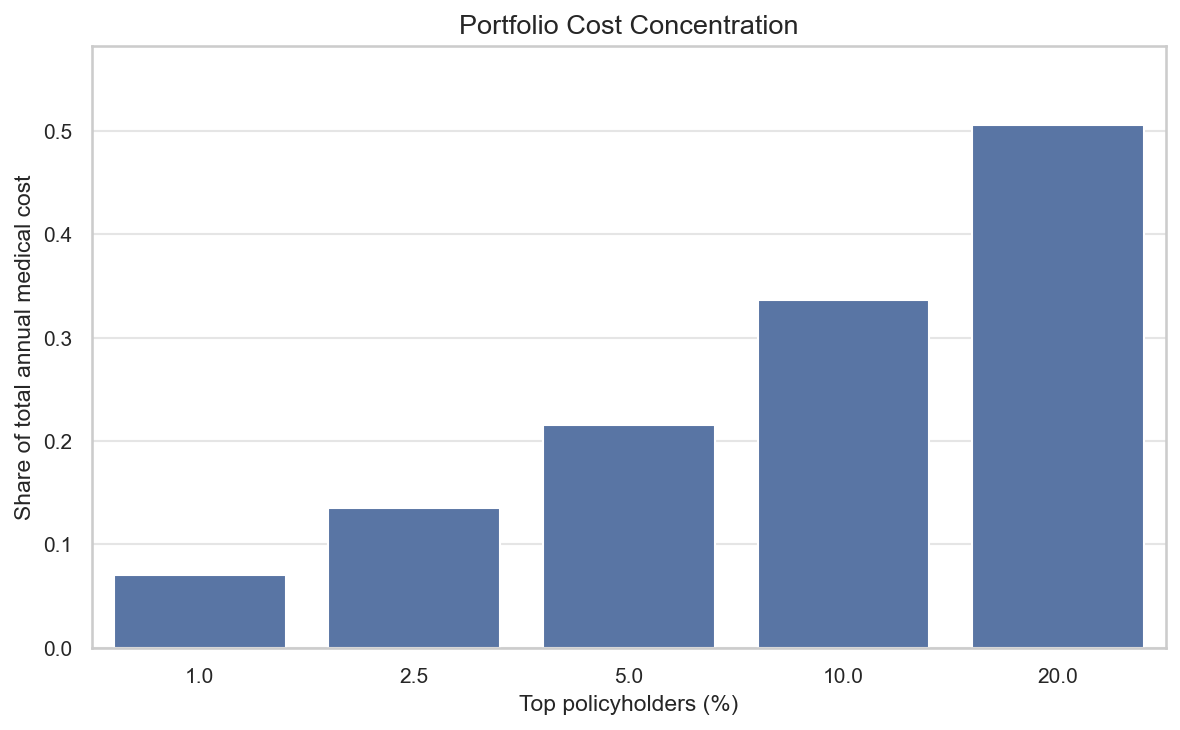

In [22]:
tail_concentration_export = tail_concentration.copy()

tail_concentration_export = tail_concentration_export.rename(columns={
    "top_percent": "Top policyholders (%)",
    "n_policyholders": "n policyholders",
    "cost_share": "Cost share",
})

display(tail_concentration_export)

export_report_table(
    table=tail_concentration_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_tail_concentration",
    caption="Share of total portfolio cost generated by the highest-cost policyholders.",
    label="tab:02-tail-concentration",
    index=False,
    float_format="%.4f",
)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

sns.barplot(
    data=tail_concentration_export,
    x="Top policyholders (%)",
    y="Cost share",
    ax=ax,
)

ax.set_title("Portfolio Cost Concentration")
ax.set_xlabel("Top policyholders (%)")
ax.set_ylabel("Share of total annual medical cost")
ax.set_ylim(0, max(tail_concentration_export["Cost share"]) * 1.15)

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_tail_concentration",
)

plt.show()

In [23]:
def mean_excess_table(data: pd.Series, quantiles=None) -> pd.DataFrame:
    if quantiles is None:
        quantiles = np.arange(0.80, 0.995, 0.01)

    rows = []

    for q in quantiles:
        threshold = data.quantile(q)
        excesses = data[data > threshold] - threshold

        rows.append({
            "quantile": q,
            "threshold": threshold,
            "n_exceedances": len(excesses),
            "mean_excess": excesses.mean()
        })

    return pd.DataFrame(rows)

,quantile,threshold,n_exceedances,mean_excess
10,0.90,6227.0920,10000,3885.052012
11,0.91,6547.3269,9000,3979.088006
12,0.92,6944.3900,8000,4054.738756
13,0.93,7380.3400,6999,4168.591420
14,0.94,7936.4440,6000,4260.441255
15,0.95,8570.3505,5000,4416.414762
16,0.96,9380.9956,4000,4614.429685
17,0.97,10496.0623,3000,4860.472980
18,0.98,12131.4906,2000,5284.859200
19,0.99,15293.6822,1000,6039.087930


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_mean_excess_table.csv
Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Figures\fig_02_mean_excess_plot.png


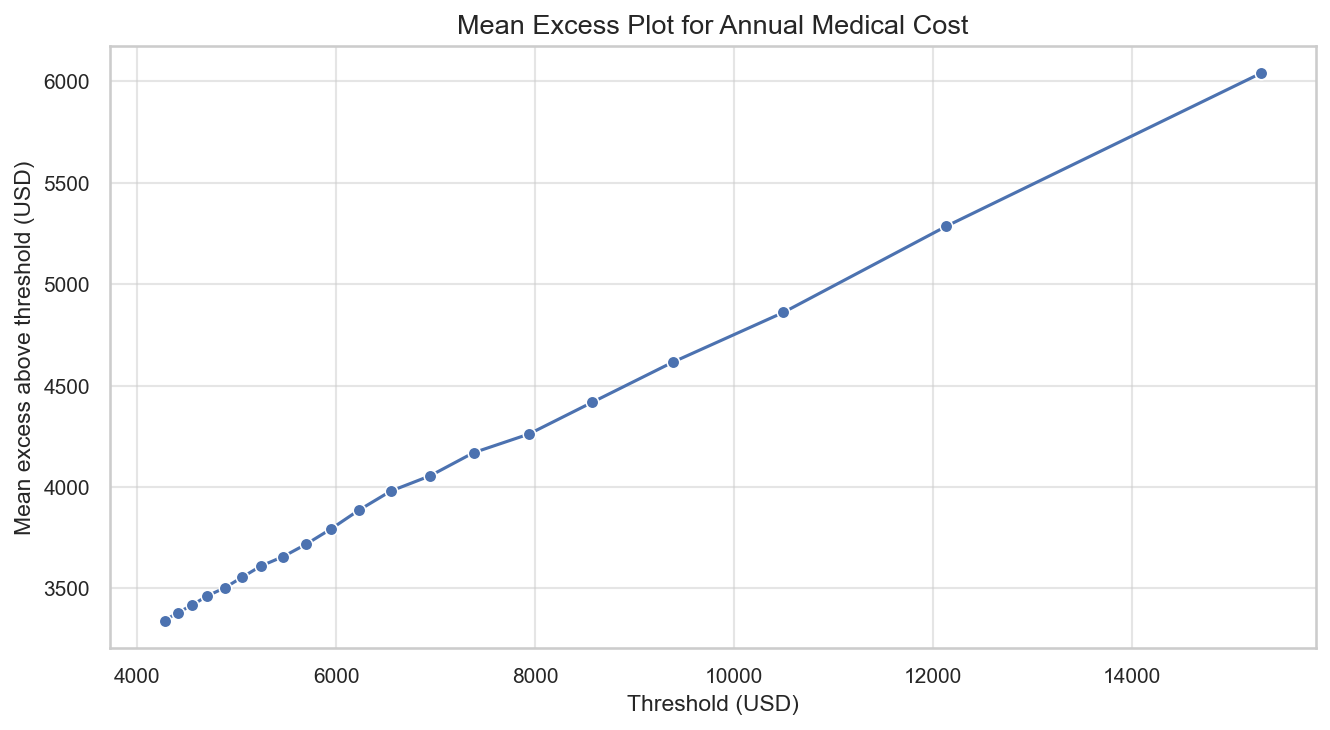

In [24]:
me_table = mean_excess_table(df[target])

display(me_table.tail(10))

fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

sns.lineplot(
    data=me_table,
    x="threshold",
    y="mean_excess",
    marker="o",
    ax=ax,
)

ax.set_title("Mean Excess Plot for Annual Medical Cost")
ax.set_xlabel("Threshold (USD)")
ax.set_ylabel("Mean excess above threshold (USD)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_02_mean_excess_plot",
)

plt.show()

In [25]:
variance_by_hospital = (
    df.groupby("hospitalizations_grouped", observed=True)[target]
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .round(2)
)

variance_by_hospital

,n,mean,std,median,iqr
hospitalizations_grouped,,,,,
0,91031,2810.44,2827.94,1977.55,2359.68
1,8582,4919.63,4685.89,3539.12,4104.35
2+,387,7461.11,7034.13,5108.38,6523.50


In [26]:
variance_by_hospital_export = (
    variance_by_hospital
    .reset_index()
    .rename(columns={
        "hospitalizations_grouped": "Hospitalisations in last 3 years",
        "n": "n",
        "mean": "Mean cost (USD)",
        "std": "Standard deviation (USD)",
        "median": "Median cost (USD)",
        "iqr": "IQR (USD)",
    })
)

display(variance_by_hospital_export)

export_report_table(
    table=variance_by_hospital_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_variance_by_hospitalisation",
    caption="Dispersion of annual medical cost by grouped hospitalisation history.",
    label="tab:02-variance-by-hospitalisation",
    index=False,
)

,Hospitalisations in last 3 years,n,Mean cost (USD),Standard deviation (USD),Median cost (USD),IQR (USD)
0,0,91031,2810.44,2827.94,1977.55,2359.68
1,1,8582,4919.63,4685.89,3539.12,4104.35
2,2+,387,7461.11,7034.13,5108.38,6523.50


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_variance_by_hospitalisation.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_variance_by_hospitalisation.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_variance_by_hospitalisation.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_variance_by_hospitalisation.tex')}

In [27]:
variance_by_chronic = (
    df.groupby("chronic_count_grouped", observed=True)[target]
    .agg(
        n="size",
        mean="mean",
        std="std",
        median="median",
        iqr=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .round(2)
)

variance_by_chronic

,n,mean,std,median,iqr
chronic_count_grouped,,,,,
0,46532,2176.33,2127.75,1558.97,1778.05
1,37579,3332.01,3171.20,2415.40,2705.87
2,13111,4438.19,4067.45,3249.83,3613.25
3,2452,5671.43,5338.14,4137.85,4349.46
4+,326,7260.65,7137.06,5260.05,6538.42


In [28]:
variance_by_chronic_export = (
    variance_by_chronic
    .reset_index()
    .rename(columns={
        "chronic_count_grouped": "Chronic disease count group",
        "n": "n",
        "mean": "Mean cost (USD)",
        "std": "Standard deviation (USD)",
        "median": "Median cost (USD)",
        "iqr": "IQR (USD)",
    })
)

display(variance_by_chronic_export)

export_report_table(
    table=variance_by_chronic_export,
    table_dir=TABLE_DIR,
    file_stem="tab_02_variance_by_chronic_count",
    caption="Dispersion of annual medical cost by grouped chronic disease count.",
    label="tab:02-variance-by-chronic-count",
    index=False,
)

,Chronic disease count group,n,Mean cost (USD),Standard deviation (USD),Median cost (USD),IQR (USD)
0,0,46532,2176.33,2127.75,1558.97,1778.05
1,1,37579,3332.01,3171.20,2415.40,2705.87
2,2,13111,4438.19,4067.45,3249.83,3613.25
3,3,2452,5671.43,5338.14,4137.85,4349.46
4,4+,326,7260.65,7137.06,5260.05,6538.42


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_variance_by_chronic_count.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\02_model_choice_diagnostics\Tables\tab_02_variance_by_chronic_count.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_variance_by_chronic_count.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/02_model_choice_diagnostics/Tables/tab_02_variance_by_chronic_count.tex')}